In [6]:
import joblib

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from loguru import logger

pd.set_option("display.max_columns", None)

In [7]:
from src.evaluation import build_predictions_report

In [8]:
def plot_barh_by_model(results_df, x, y="model", hue=None, title="", figsize=(8, 6)):
    """Barplot horizontal genérico para comparar modelos por una métrica."""
    palette = {"ML": "#1f77b4", "Statistical": "#ff7f0e", "Naive": "#2ca02c"}
    df_sorted = results_df.sort_values(x, ascending=True)
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(df_sorted, x=x, y=y, hue=hue, hue_order=list(palette.keys()), order=df_sorted[y],
                dodge=False, palette=palette if hue else None, ax=ax)
    ax.set_title(title, loc="left", pad=20)
    ax.set_xlabel("")
    ax.set_ylabel("")
    sns.despine()
    if hue:
        ax.legend(title=hue, loc="upper right")
    plt.tight_layout()
    plt.show()

In [9]:
!ls ../artifacts/models/

level_01_daily_total_sales_artifact.pkl
level_01_weekly_total_sales_artifact.pkl
level_02_daily_state_sales_artifact.pkl
level_02_weekly_state_sales_artifact.pkl
level_03_daily_cat_sales_artifact.pkl
level_03_weekly_cat_sales_artifact.pkl
level_04_daily_dept_sales_artifact.pkl
level_04_weekly_dept_sales_artifact.pkl
level_05_daily_state_cat_sales_artifact.pkl
level_05_weekly_state_cat_sales_artifact.pkl
level_06_daily_store_sales_artifact.pkl
level_06_weekly_store_sales_artifact.pkl
level_07_daily_state_dept_sales_artifact.pkl
level_07_weekly_state_dept_sales_artifact.pkl
level_08_daily_store_cat_sales_artifact.pkl
level_08_weekly_store_cat_sales_artifact.pkl
level_09_daily_store_dept_sales_artifact.pkl
level_09_weekly_store_dept_sales_artifact.pkl
registry.json
versions


In [13]:
ARTIFACT = "level_09_daily_store_dept_sales_artifact"

In [14]:
import joblib
from src.data.dataset import reconstruct_test_data

artifact_path = f"../artifacts/models/{ARTIFACT}.pkl"
artifact = joblib.load(artifact_path)

model = artifact["model"]
FEATURES = artifact["features"]
feature_importance = artifact["feature_importance"]
results_df = artifact["results_df"]

X_test, y_test, artifact["train"], artifact["test"] = reconstruct_test_data(artifact)

2026-09-15 20:55:51.850 | INFO     | src.data.dataset:load_data:58 - level_09_daily_store_dept | target=sales | 135,870 filas | 191 features (9 categóricas)
2026-09-15 20:55:52.021 | INFO     | src.data.temporal_split:log_summary:41 - Train : 2011-01-29 to 2015-04-26 (1,549 days, 108,430 rows)
2026-09-15 20:55:52.023 | INFO     | src.data.temporal_split:log_summary:42 - Valid : 2015-04-27 to 2016-04-24 (364 days, 25,480 rows)
2026-09-15 20:55:52.027 | INFO     | src.data.temporal_split:log_summary:43 - Test  : 2016-04-25 to 2016-05-22 (28 days, 1,960 rows)
2026-09-15 20:55:52.694 | INFO     | src.data.dataset:split_data:119 - Features: 154 (4 categóricas)


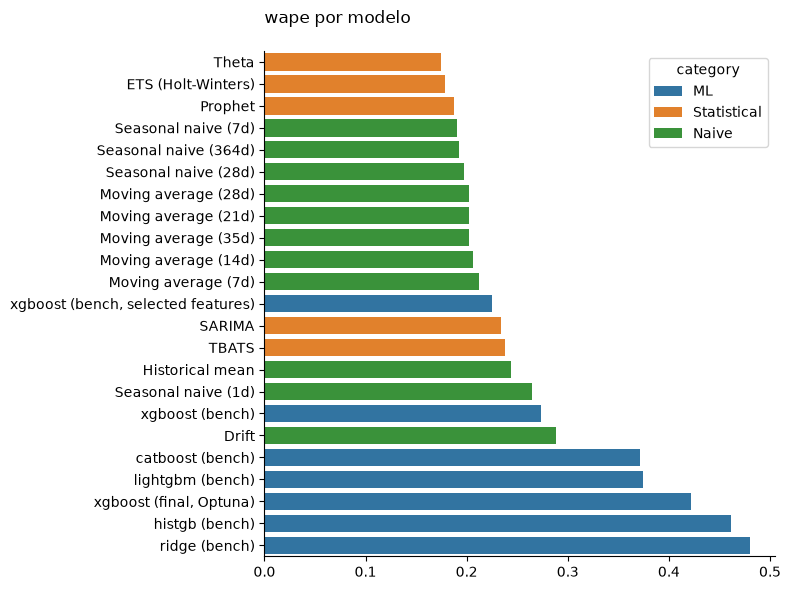

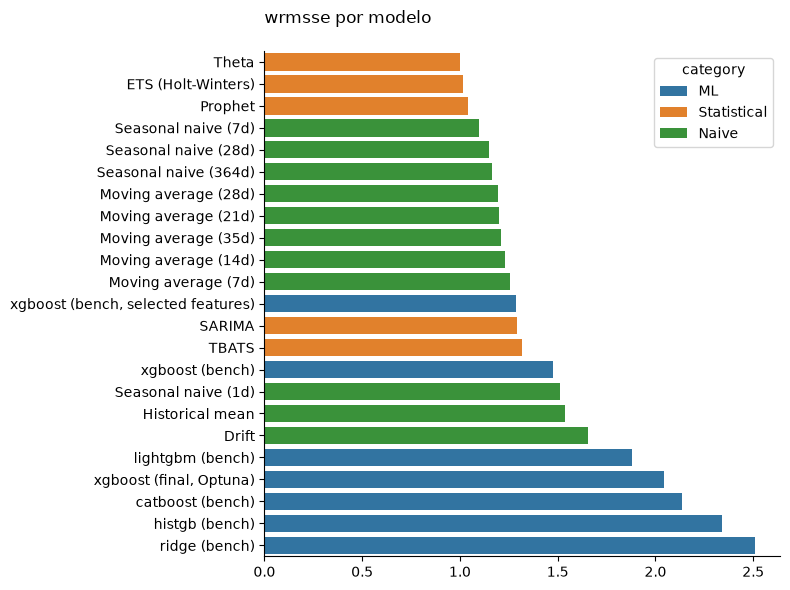

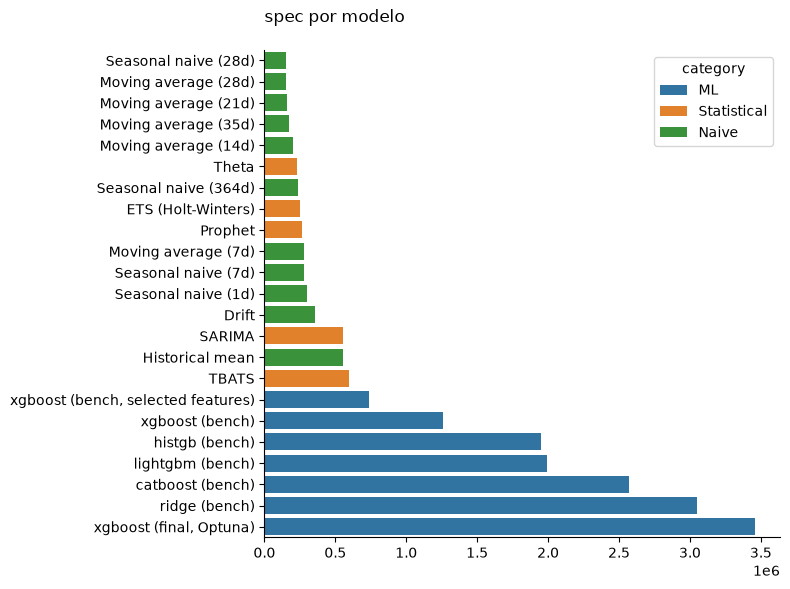

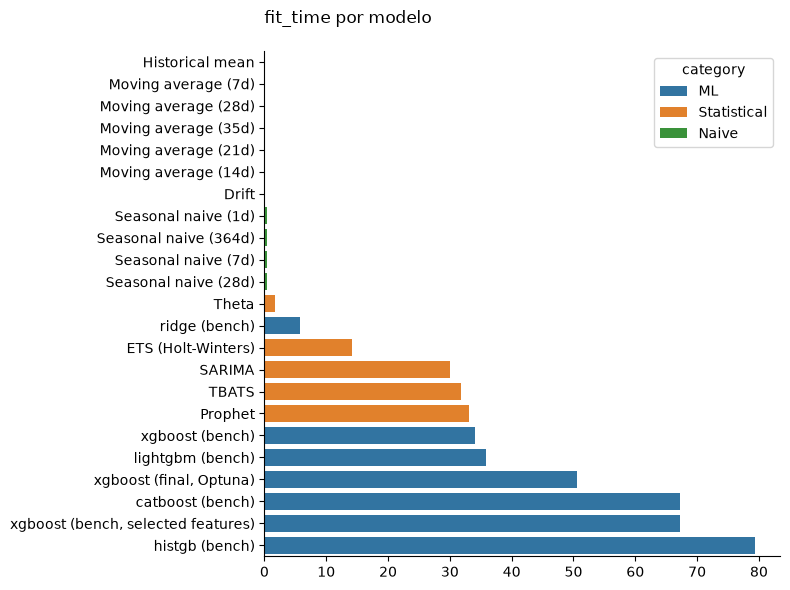

In [15]:
#['wape', 'wrmsse', 'mae', 'rmse', 'mape', 'smape', 'bias', 'rmsle', 'tracking_signal', 'spec', 'mase', 'fit_time']:
for col in ['wape', 'wrmsse', 'spec','fit_time']:
    plot_barh_by_model(results_df, hue="category", x=col, y="model", title=f"{col} por modelo")

## Explicación modelo

In [ ]:
import shap

explainer = artifact["explainer"]

X_shap = model.prepare(X_test.sample(n=min(300_000, len(X_test)), random_state=42))

shap_values = explainer.shap_values(X_shap)
shap_df = pd.DataFrame(shap_values, columns=X_shap.columns, index=X_shap.index)

importance_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

print(importance_df)

                            feature  mean_abs_shap
10                     te_snap_mean    1051.232422
12                             lag4     948.416504
15   rolling_mean_lag4_window_size4     654.803284
17  rolling_mean_lag4_window_size13     149.171982
0                      event_name_1      59.981709
13                            lag17      51.419373
4                               day      37.546856
14   rolling_min_lag1_window_size13      32.725391
8                   days_to_newyear      31.745466
11                    adi_expanding      29.345404
16    rolling_std_lag4_window_size4      23.873734
9                       te_cat_mean      21.849728
18   rolling_std_lag4_window_size13      20.217863
5                        weekofyear      19.356810
21   rolling_std_lag52_window_size4      10.151712
22  rolling_std_lag52_window_size13       9.480798
23  rolling_min_lag52_window_size13       7.792738
24  rolling_max_lag52_window_size13       7.342111
7                  price_volati

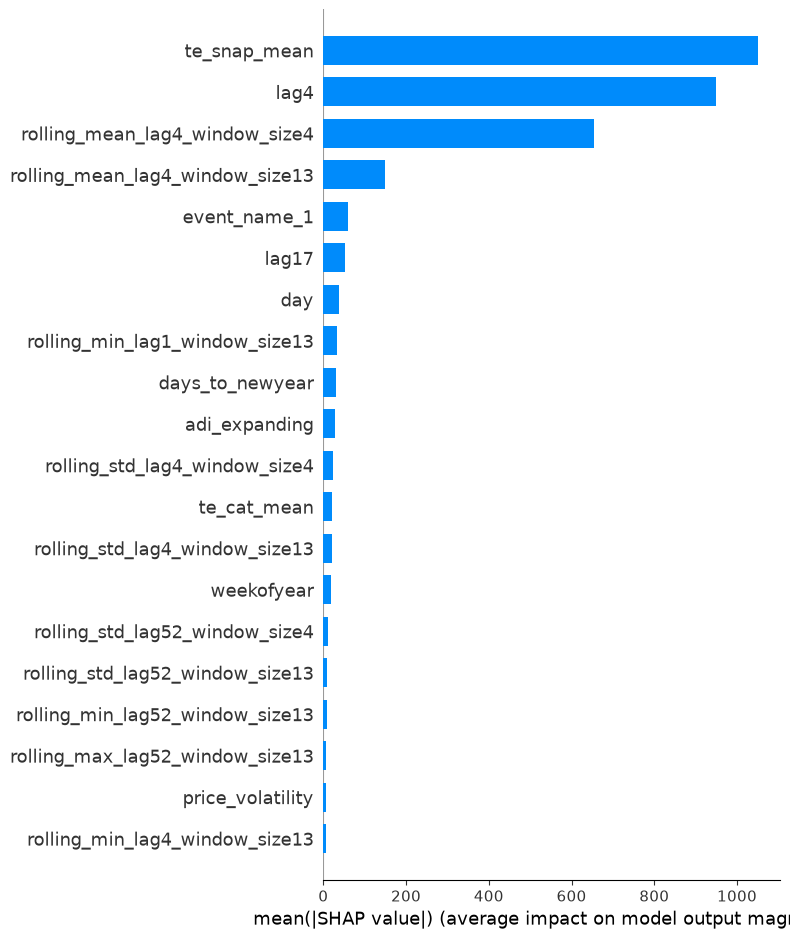

In [ ]:
shap.summary_plot(shap_values, X_shap, plot_type="bar")

In [ ]:
#shap.summary_plot(shap_values, X_shap)

# Predicciones

In [ ]:
from src.evaluation import analizar_prediccion, plot_forecast

In [ ]:
metrics_test_final, df_pred = build_predictions_report(artifact['train'], artifact['test'], y_test, model.predict(X_test), target_col=artifact['target'])

print(f"Total sales: {df_pred['sales'].sum():,.0f}")
print(f"Total predicted: {df_pred['y_pred'].sum():,.0f}")
print(f"Diff: {df_pred['y_pred'].sum() - df_pred['sales'].sum():,.0f}")

print(f"Test WAPE: {metrics_test_final['wape']:.1%}")
print(f"Test BIAS: {metrics_test_final['bias']:.1%}")

print(f"Test WRMSSE: {metrics_test_final['wrmsse']:.3f}")

Total sales: 1,231,764
Total predicted: 1,173,981
Diff: -57,783
Test WAPE: 7.6%
Test BIAS: -4.7%
Test WRMSSE: 0.492


In [ ]:
from src.evaluation import build_series_metrics

df_metrics = build_series_metrics(artifact['train'], df_pred, target_col=artifact['target'], weight_level=["date"])
df_metrics.head(5)

,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
series_id,,,,,,,,,,,,,,,
FOODS_3_FOODS_CA_3_CA,4,4,77367.0,80322.0,-2955.0,3739.0,194847.031250,0.049948,0.048328,0.038195,0.055607,-3.161273,0.254185,0.384044,638.0625
FOODS_3_FOODS_CA_1_CA,4,4,65999.0,60462.0,5537.0,5537.0,167972.828125,0.043059,0.083895,-0.083895,0.092783,4.000000,0.480082,0.850901,2245.5000
HOUSEHOLD_1_HOUSEHOLD_CA_3_CA,4,4,38478.0,41365.0,-2887.0,2887.0,163889.625000,0.042012,0.075030,0.075030,0.084045,-4.000000,0.570974,1.012311,448.3125
FOODS_3_FOODS_WI_2_WI,4,4,67991.0,63954.0,4037.0,4741.0,154892.250000,0.039706,0.069730,-0.059376,0.088856,3.406032,0.569737,0.544089,1558.0000
FOODS_3_FOODS_CA_2_CA,4,4,57132.0,53380.0,3752.0,3752.0,146760.937500,0.037622,0.065672,-0.065672,0.071398,4.000000,0.593113,1.297453,1533.5625


In [ ]:
df_metrics.sort_values('wape').round(4)

,n_days,n_days_with_sales,sales,y_pred,error,abs_error,gross_sales,gross_sales_pct,wape,bias,rmsle,tracking_signal,wrmsse,mase,spec
series_id,,,,,,,,,,,,,,,
FOODS_3_FOODS_CA_4_CA,4,4,33353.0,33071.0,282.0,724.0,87654.726562,0.0225,0.0217,-0.0085,0.0248,1.5580,0.1515,0.2819,230.2500
HOUSEHOLD_1_HOUSEHOLD_CA_1_CA,4,4,21223.0,21750.0,-527.0,527.0,86271.875000,0.0221,0.0248,0.0248,0.0251,-4.0000,0.1743,0.3496,83.4375
FOODS_3_FOODS_TX_2_TX,4,4,56187.0,55562.0,625.0,1517.0,135407.515625,0.0347,0.0270,-0.0111,0.0333,1.6480,0.1674,0.2540,244.6250
HOUSEHOLD_2_HOUSEHOLD_TX_2_TX,4,4,5719.0,5834.0,-115.0,201.0,26228.009766,0.0067,0.0351,0.0201,0.0350,-2.2886,0.2365,0.4772,27.5000
HOUSEHOLD_1_HOUSEHOLD_WI_3_WI,4,4,18133.0,18299.0,-166.0,668.0,63012.140625,0.0162,0.0368,0.0092,0.0407,-0.9940,0.2294,0.3306,55.1250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FOODS_1_FOODS_WI_2_WI,4,4,13170.0,10114.0,3056.0,3056.0,35775.050781,0.0092,0.2320,-0.2320,0.2724,4.0000,1.5437,2.3468,1624.3125
HOBBIES_2_HOBBIES_CA_4_CA,4,4,608.0,511.0,97.0,147.0,1404.229980,0.0004,0.2418,-0.1595,0.2666,2.6395,1.3462,1.8910,32.6875
HOBBIES_2_HOBBIES_TX_1_TX,4,4,1238.0,910.0,328.0,328.0,2613.530029,0.0007,0.2649,-0.2649,0.3325,4.0000,2.2716,2.6591,130.3125


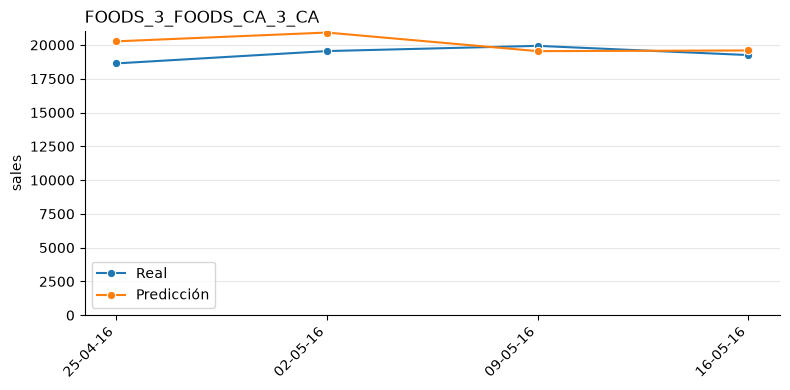

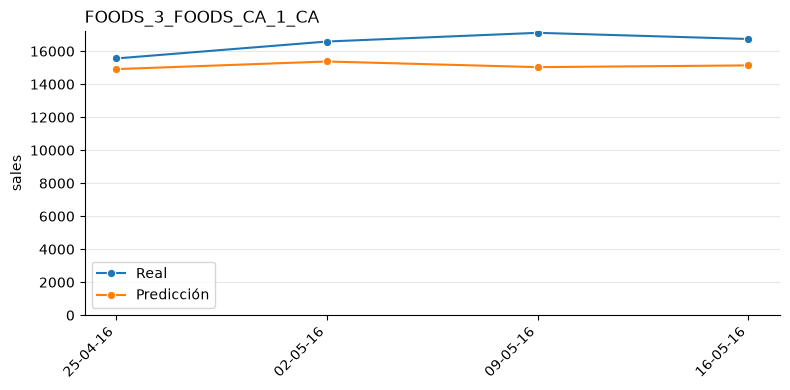

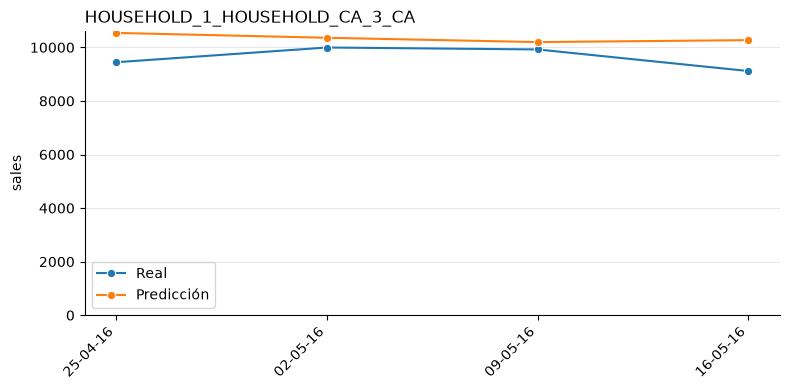

In [ ]:
for i in df_metrics.sort_values('gross_sales_pct', ascending=False).head(3).index:
    plot_forecast(df_pred, 'sales', series_id=i)

In [ ]:
SERIES = 'HOUSEHOLD'
df_sample = df_pred.query(f'series_id == "{SERIES}"').copy()

#display(df_sample)

top_best_dates = df_pred.query(f'series_id == "{SERIES}"').nsmallest(2, 'wape')['date']
top_error_dates = df_pred.query(f'series_id == "{SERIES}"').nlargest(2, 'wape')['date']

#plot_forecast(df_pred, 'sales', series_id=SERIES)
#plot_forecast(df_pred, 'gross_sales', series_id=SERIES)
#plot_forecast(df_pred, 'wape', series_id=SERIES)
#plot_forecast(df_pred, 'bias', series_id=SERIES)

In [ ]:
SERIES = "FOODS_2_FOODS"

for i in top_error_dates:
    print("#"*50,f"Date: {i}", "#"*50)
    analizar_prediccion(test_df=artifact['test'], X_test=X_test, df_pred=df_pred, target_col=artifact['target'], series_id=SERIES, explainer=explainer, date=i)

In [ ]:
for i in top_best_dates:
    print("#"*50,f"Date: {i}", "#"*50)
    analizar_prediccion(test_df=artifact['test'], X_test=X_test, df_pred=df_pred, target_col=artifact['target'], series_id=SERIES, explainer=explainer, date=i)